<a href="https://colab.research.google.com/github/famouxsss24/4WD_4wheelguys/blob/vision/notebooks/train-yolo11-object-detection-on-custom-dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO11 Object Detection on a Custom Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO11 builds on the advancements introduced in YOLOv9 and YOLOv10 earlier this year, incorporating improved architectural designs, enhanced feature extraction techniques, and optimized training methods.

YOLO11m achieves a higher mean mAP score on the COCO dataset while using 22% fewer parameters than YOLOv8m, making it computationally lighter without sacrificing performance.

YOLOv11 is available in 5 different sizes, ranging from `2.6M` to `56.9M` parameters, and capable of achieving from `39.5` to `54.7` mAP on the COCO dataset.

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [3]:
!nvidia-smi

Sat Apr 25 03:29:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [4]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [5]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.7/112.6 GB disk)


In [6]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("4guys")
project = workspace.project("4guysguys")
version = project.version(2)
dataset = version.download("yolov11")

mkdir: cannot create directory ‘/content/datasets’: File exists
/content/datasets
loading Roboflow workspace...
loading Roboflow project...


## Custom Training

In [7]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=100 imgsz=320 plots=True

/content
New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/datasets/4guysguys-2/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=320, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None,

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [9]:
!ls {HOME}/runs/detect/train/

args.yaml					    state_dict.pt
confusion_matrix_normalized.png			    train_batch0.jpg
confusion_matrix.png				    train_batch10080.jpg
events.out.tfevents.1777084516.fab82c4105f2.1581.0  train_batch10081.jpg
F1_curve.png					    train_batch10082.jpg
labels_correlogram.jpg				    train_batch1.jpg
labels.jpg					    train_batch2.jpg
model_artifacts.json				    val_batch0_labels.jpg
P_curve.png					    val_batch0_pred.jpg
PR_curve.png					    val_batch1_labels.jpg
R_curve.png					    val_batch1_pred.jpg
results.csv					    val_batch2_labels.jpg
results.png					    val_batch2_pred.jpg
roboflow_deploy.zip				    weights


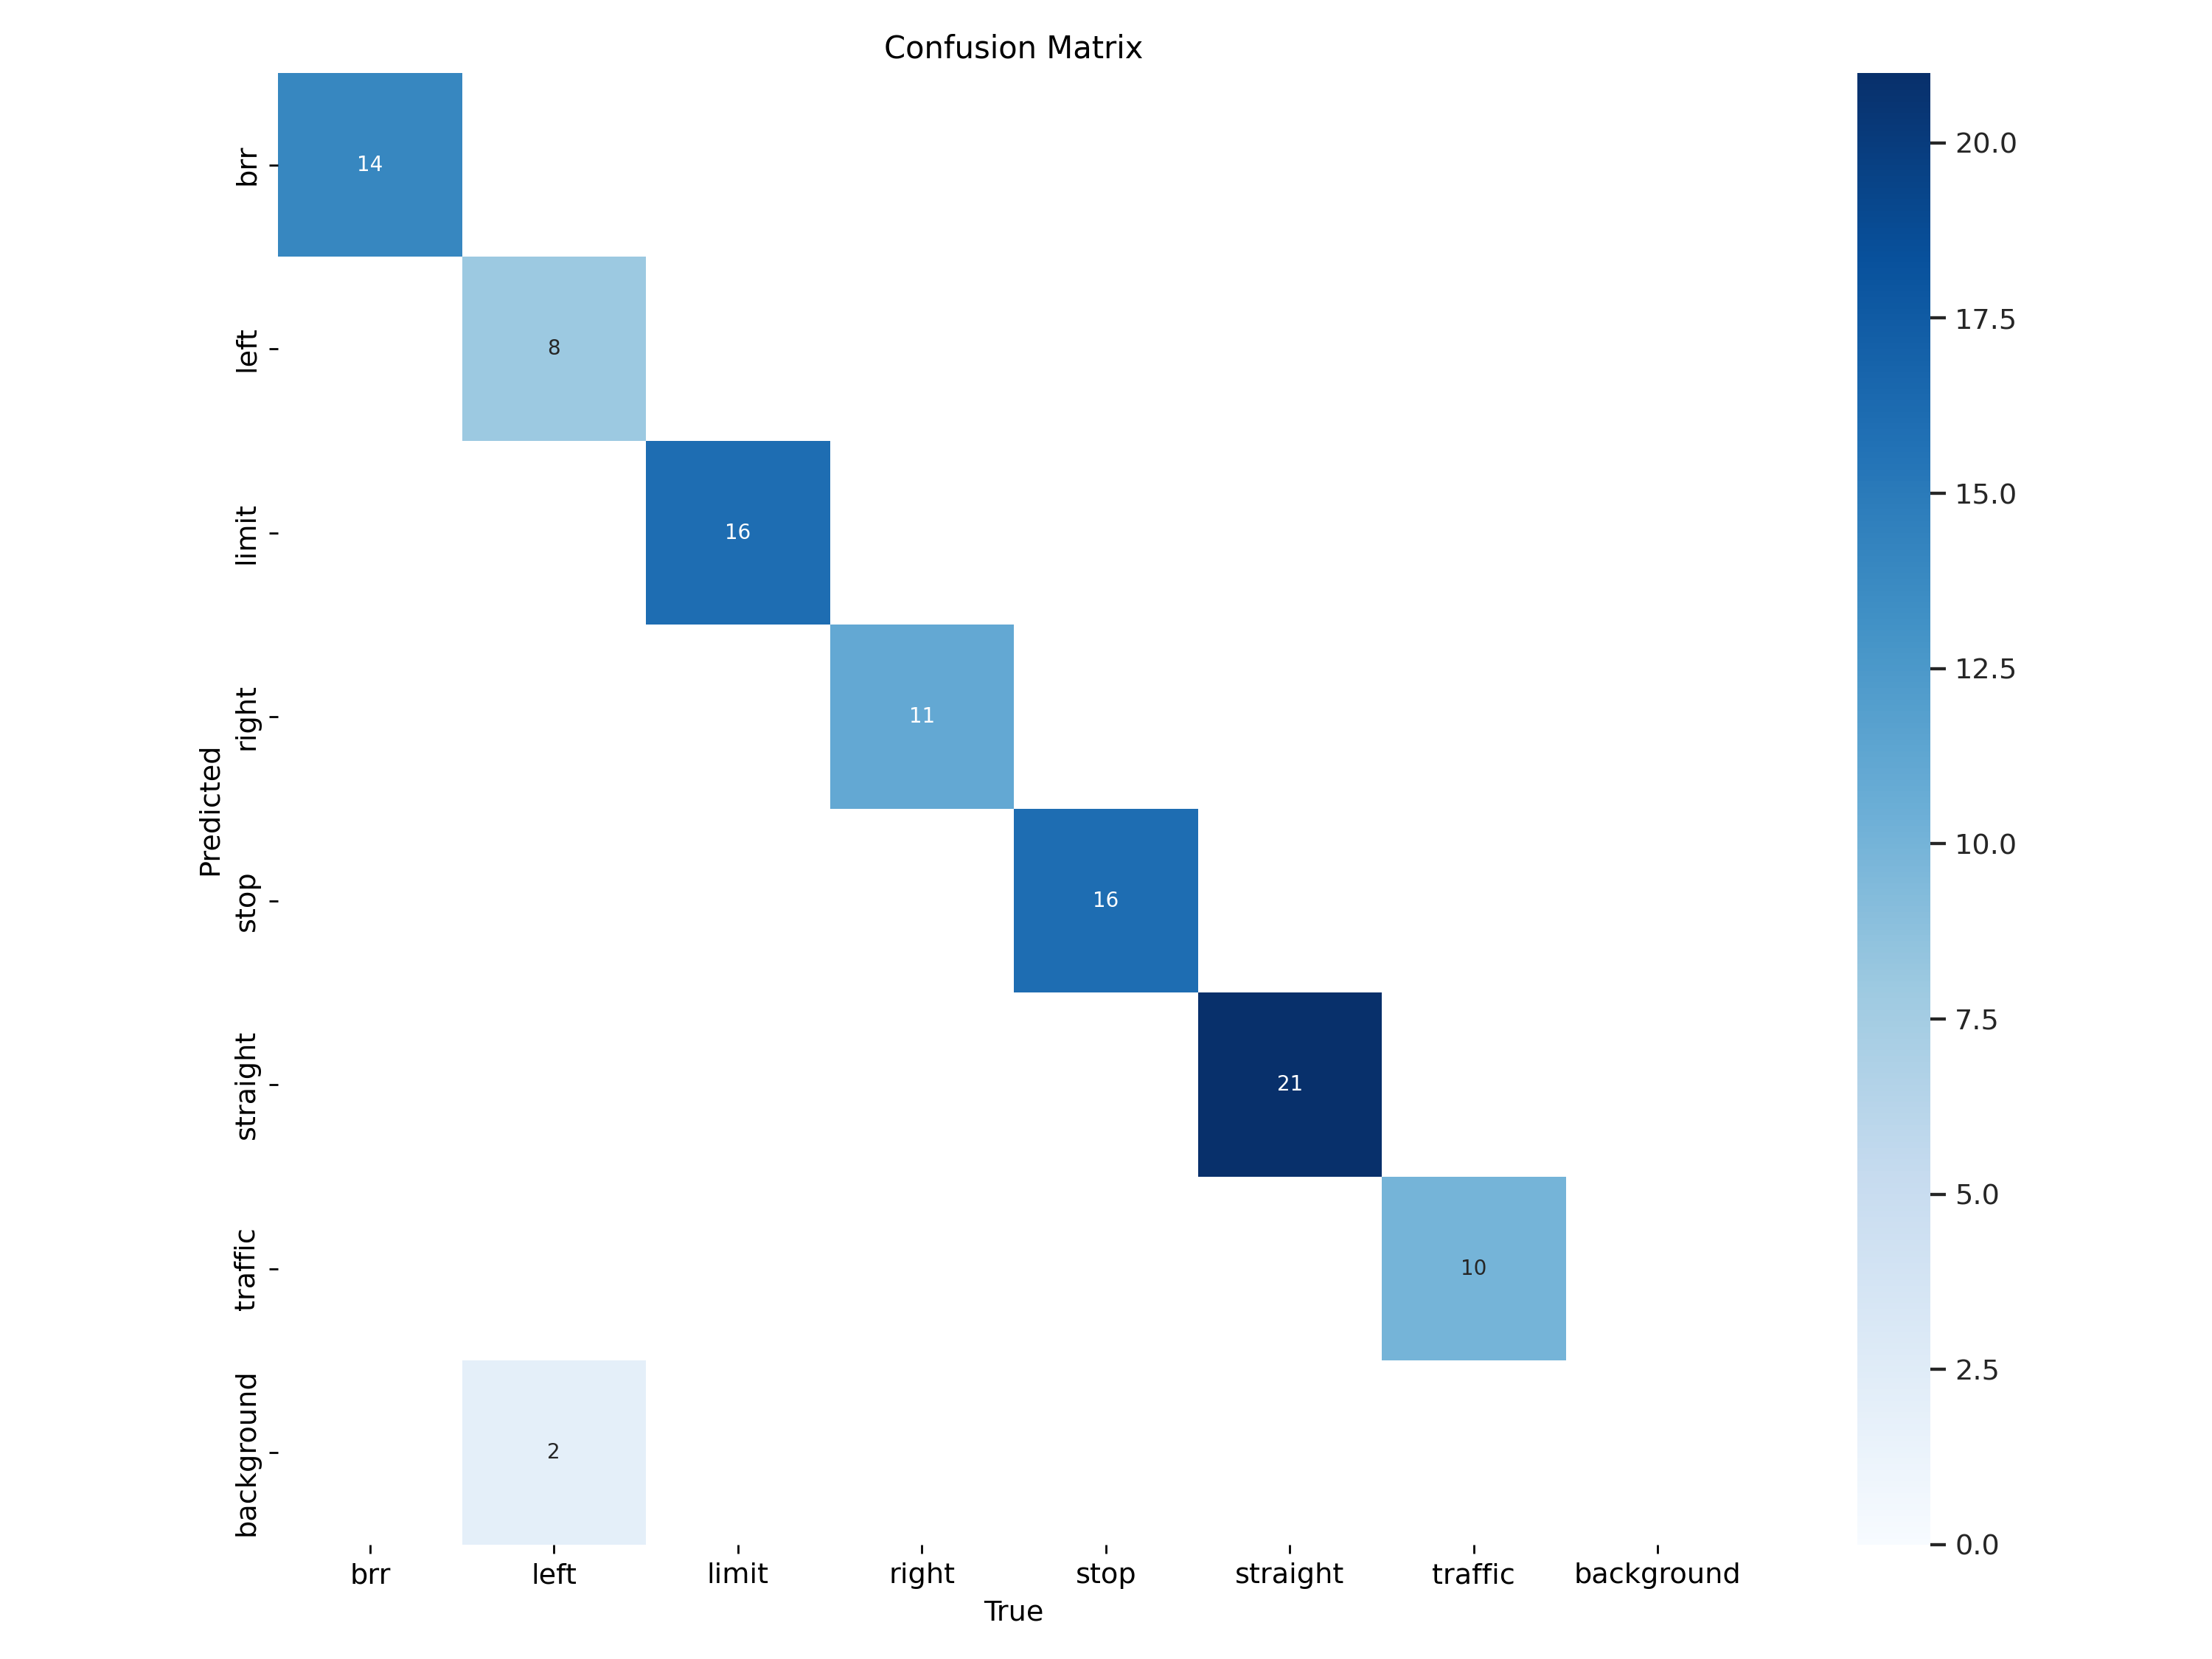

In [10]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

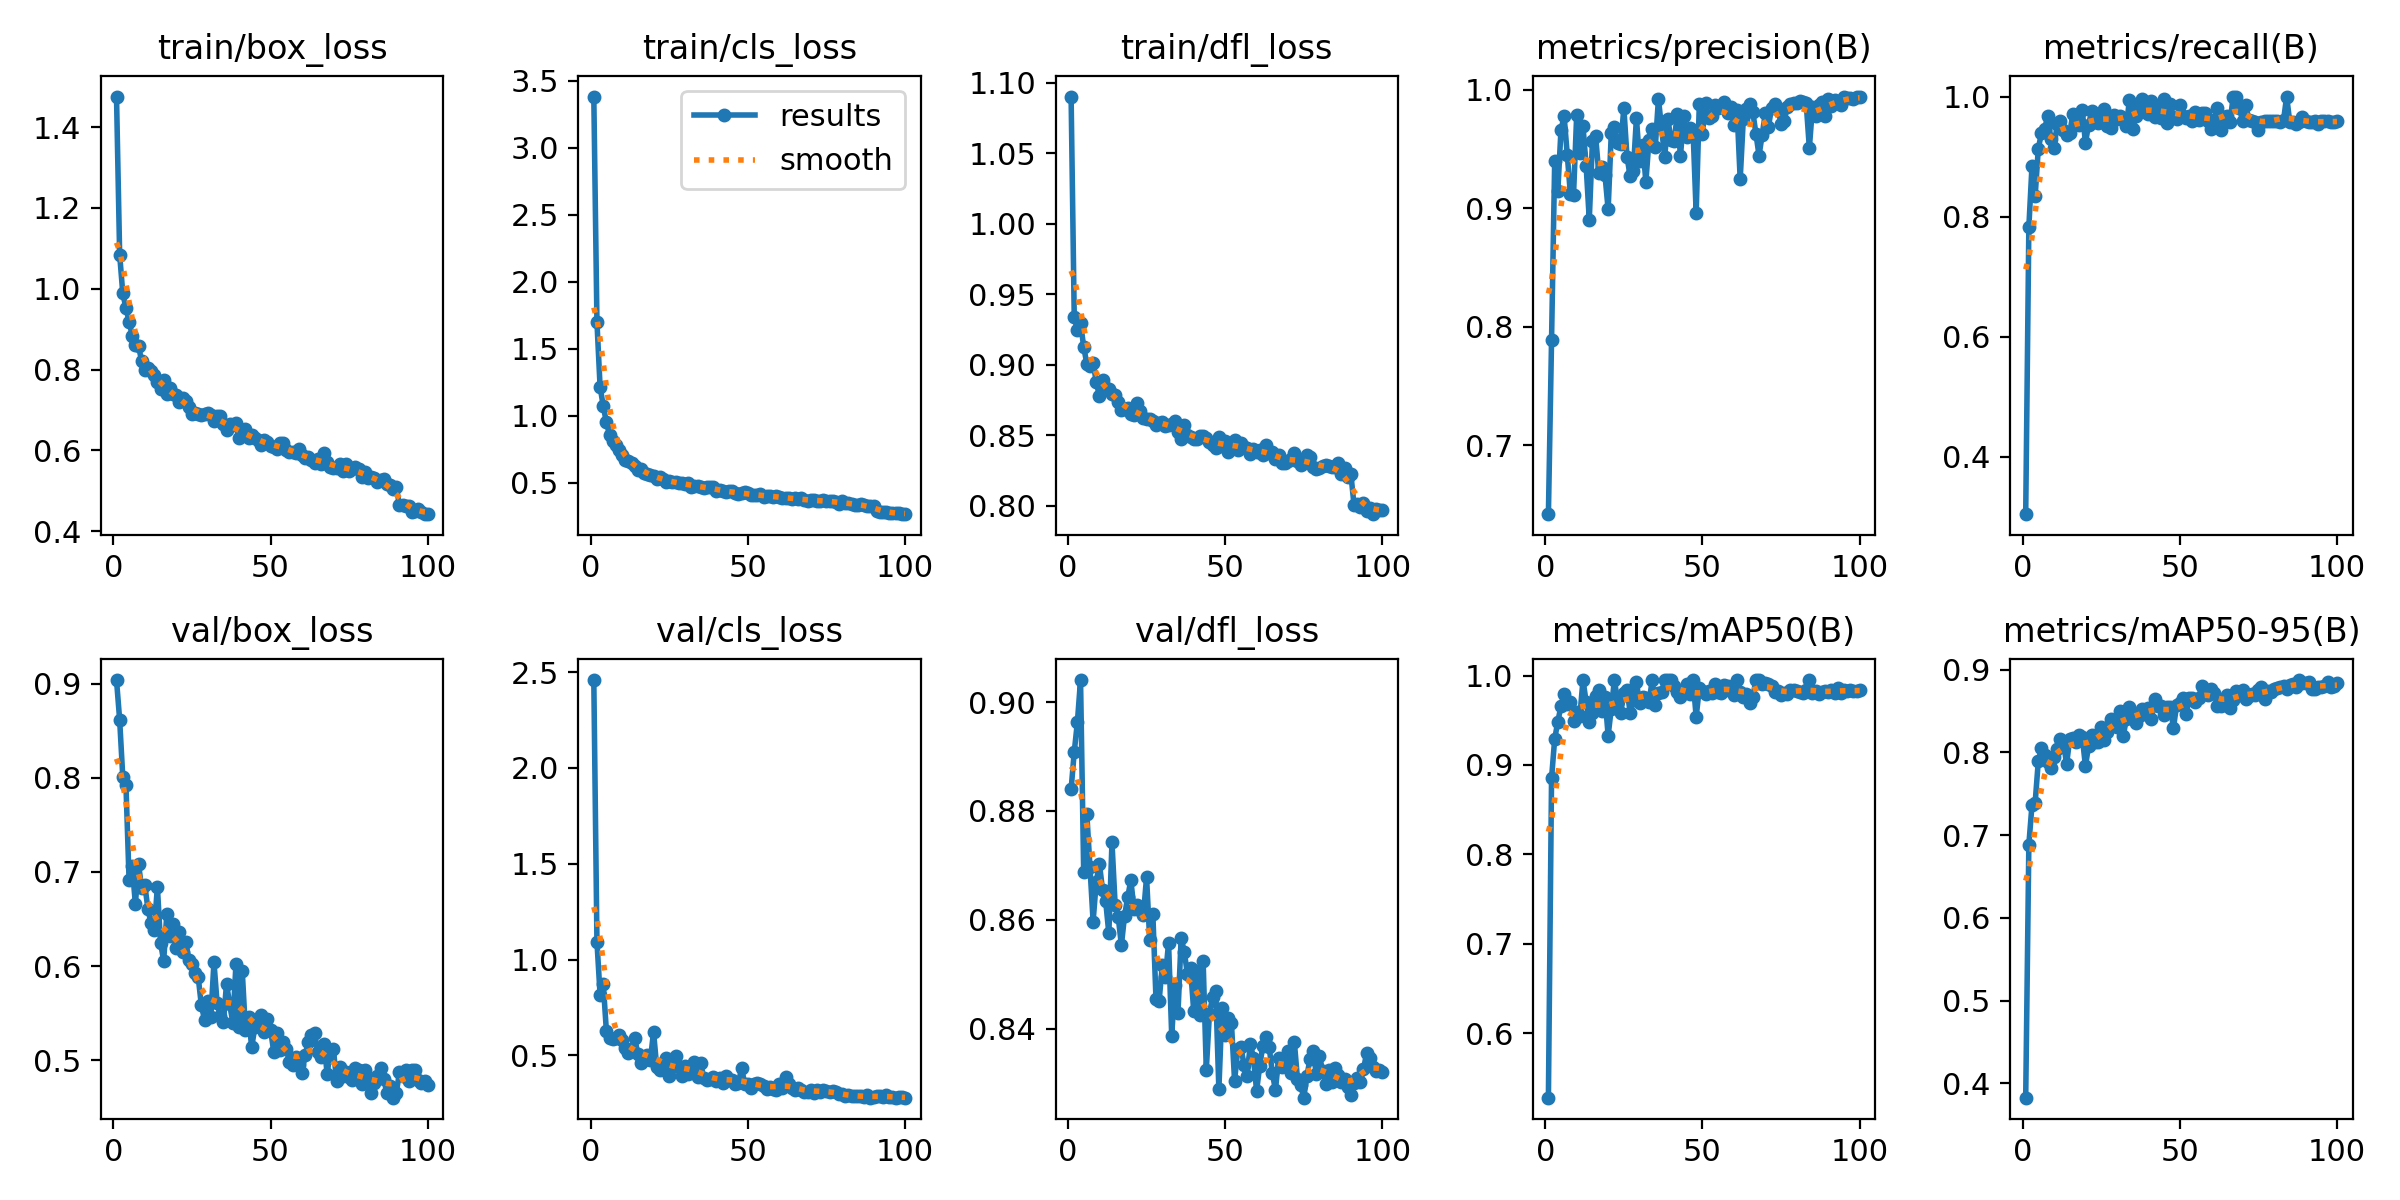

In [11]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

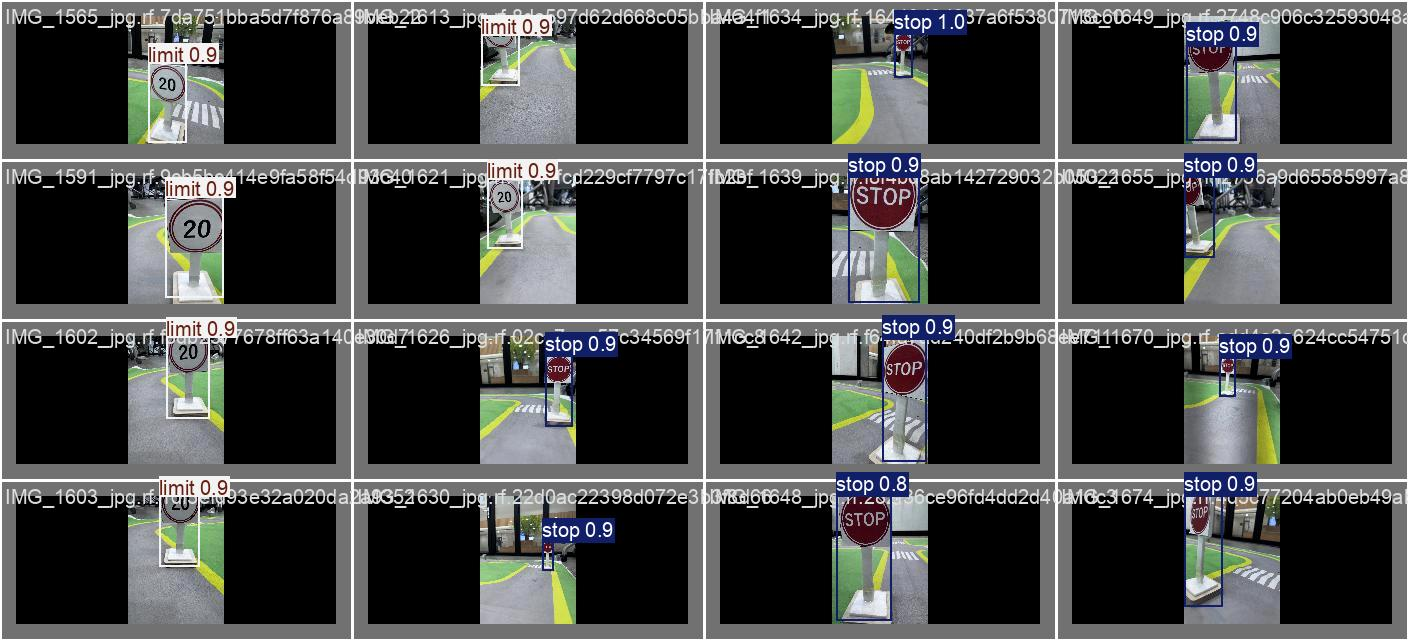

In [12]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [13]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs
val: Scanning /content/datasets/4guysguys-2/valid/labels.cache... 113 images, 15 backgrounds, 0 corrupt: 100% 113/113 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 97, len(boxes) = 98. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 8/8 [00:01<00:00,  5.92it/s]
                   all        113         98      0.989      0.957      0.982      0.888
                   brr         14         14       0.99          1      0.995       0.88
                  left         10         10      0.989        0.7      0.901      0.735
                 limit         16     

## Inference with custom model

In [14]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 238 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs

image 1/77 /content/datasets/4guysguys-2/test/images/IMG_1614_jpg.rf.ed5247a9c95faaa92055cdb7f7634744.jpg: 128x320 1 limit, 48.5ms
image 2/77 /content/datasets/4guysguys-2/test/images/IMG_1615_jpg.rf.c3375e251ca9c151b38908a0ae9344ae.jpg: 128x320 1 limit, 10.8ms
image 3/77 /content/datasets/4guysguys-2/test/images/IMG_1636_jpg.rf.6d0726b6e95fe44cbd4673d85c6266ab.jpg: 128x320 1 stop, 7.7ms
image 4/77 /content/datasets/4guysguys-2/test/images/IMG_1638_jpg.rf.300e6ba199ee730debe2a0d5b33fc511.jpg: 128x320 1 stop, 7.4ms
image 5/77 /content/datasets/4guysguys-2/test/images/IMG_1645_jpg.rf.10f1b7d32ae5f78949d1fb99bac27071.jpg: 128x320 1 stop, 7.4ms
image 6/77 /content/datasets/4guysguys-2/test/images/IMG_1658_jpg.rf.cf1f1ba000ef0614a8062acc0578ff88.jpg: 128x320 1 stop, 7.4ms
image 7/77 /content/datasets/4guysguys-2/test/images/IM

**NOTE:** Let's take a look at few results.

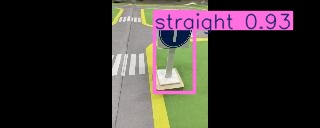

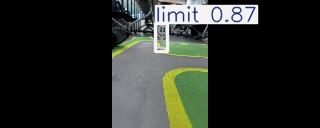

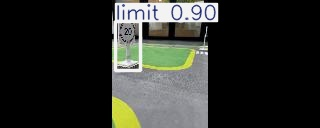

In [15]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv11 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv11 weights.

In [5]:
from roboflow import Roboflow
from google.colab import userdata

# 1. 초기화 (이전에 실행했어도 한 번 더 해주는 게 안전합니다)
ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# 2. 내 프로젝트 정보 직접 입력 (아까 스크린샷에 있던 정보 기준)
workspace_name = "4guys"
project_name = "4guysguys"
version_number = 2  # 현재 작업 중인 버전 번호

# 3. 객체 다시 불러오기
project = rf.workspace("4guys").project("4guysguys")
version = project.version(2)

# 4. Deploy 실행 (학습된 가중치 업로드)
# model_path는 'best.pt'가 들어있는 폴더 경로입니다.
# 보통 '/content/datasets/runs/detect/train/' 입니다.
model_path = "/content/runs/detect/train2/"

version.deploy(model_type="yolov11", model_path=model_path)

print(f"\n✅ 버전 {version_number}가 Roboflow 서버에 성공적으로 배포되었습니다!")

loading Roboflow workspace...
loading Roboflow project...
An error occured when getting the model upload URL: This version already has a trained model. Please generate and train a new version in order to upload model to Roboflow.

✅ 버전 2가 Roboflow 서버에 성공적으로 배포되었습니다!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
# ONNX 변환에 필요한 필수 도구들을 설치합니다.
!pip install onnxscript onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 19.6 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO

# 1. 학습된 최상의 모델(best.pt) 불러오기
# 왼쪽 폴더 탐색기에서 runs/detect/train2/weights/best.pt 경로가 맞는지 확인하세요!
model = YOLO('/content/runs/detect/train2/weights/best.pt')

# 2. ONNX 포맷으로 변환 (핵심 설정)
# imgsz: 우리가 공들여 맞춘 320으로 고정합니다.
# opset: 12로 설정하면 라즈베리파이(OpenCV)에서 호환성이 가장 좋습니다.
onnx_path = model.export(format='onnx', imgsz=320, opset=12)

print(f"\n✅ 변환 완료! 파일 위치: {onnx_path}")

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon 2.00GHz)
YOLO11n summary (fused): 238 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/runs/detect/train2/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 11, 2100) (5.2 MB)

ONNX: starting export with onnx 1.21.0 opset 12...


W0425 04:23:29.131000 24701 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    resu

ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 8.9s, saved as '/content/runs/detect/train2/weights/best.onnx' (9.9 MB)

Export complete (9.2s)
Results saved to /content/runs/detect/train2/weights
Predict:         yolo predict task=detect model=/content/runs/detect/train2/weights/best.onnx imgsz=320  
Validate:        yolo val task=detect model=/content/runs/detect/train2/weights/best.onnx imgsz=320 data=/content/datasets/4guysguys-2/data.yaml  
Visualize:       https://netron.app

✅ 변환 완료! 파일 위치: /content/runs/detect/train2/weights/best.onnx
